### Imports 

In [4]:
#for dealing with data:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import xarray as xr

#for dealing with files:
import os
import re
from scipy.io import readsav
import h5py
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
from urllib.parse import urljoin, urlparse
import time

#for plotting (the rcParams updates are my personal perference to change font and increase fontsize)
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24,\
                     'xtick.labelsize' : 24,\
                     'ytick.labelsize' : 24,\
                     'axes.titlesize' : 24,\
                     'axes.labelsize' : 24,\
                     'date.autoformatter.minute': '%H:%M' })

# all helper functions for downloading and parsing data
import skymap_data_helper

# for contrast adjustment
import cv2

# for resolution increase
from PIL import Image

import importlib
importlib.reload(skymap_data_helper)

import math

import importlib
importlib.reload(skymap_data_helper)

from altitude_helper import plot_lat_lon, mod_plot_lat_lon



#data_yknf = readsav("./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav", verbose=False)['skymap']
#data_fsmi = readsav("./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav", verbose=False)['skymap']




### Loading Data

In [5]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/ssl/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Projecting pixels to some lat/lon

In [6]:
def project_lat_lon(az_arr, el_arr, lat_camera, lon_camera, h, skymap_110_mask):
    '''
    params: 
    az_arr = 2D azimuth array for each pixel (NaNs ok, degrees, xarray)
    el_arr = 2D elevation array for each pixel (NaNs ok, degrees, xarray, no need to be filtered)
    lat_camera = latitude of camera (degrees) --> shape [480, 553]
    lon_camera = longitude of camera (degrees) --> shape [480, 553]
    h = height you want to project azimuth and elevation to to get latitude and longitude for each pixel
    skymap_110_mask = mask for where the latitude and longitude are NaNs in the ground truth lat110 and lon110 projections

    returns: 
    lat_aurora_arr = latitudes of the aurora projected to given height h
    lon_aurora_arr = longitudes of the aurora project to give height h 
    '''

    #----- Preprocessing elevation and azimuth arrays + calculating necessary constants ------#
    # convert to radians + applying mask 
    el_arr = np.radians(np.array(el_arr))
    az_arr = np.radians(np.array(az_arr))
    
    # create elevation mask (True when valid)
    el_mask = (el_arr > np.radians(5)) & (el_arr < np.radians(90))
    
    # combine with skymap mask: True = valid pixel
    valid_mask = el_mask & (~skymap_110_mask)
    
    # set invalid pixels to NaN
    el_arr[~valid_mask] = np.nan

    # distance along ray to intersect with aurora circle
    R = 6371000 # avg radius of earth 
    t_aurora = -1*R*np.sin(el_arr) + np.sqrt(R**2*(np.sin(el_arr))**2 + 2*h*R + h**2)

    # x component of the ray when it hits the aurora circle (head-on 2D perspective)
    x_aurora = t_aurora * np.cos(el_arr)

    # angle giving the arc distance of lat/lon offset from the camera 
    phi = np.arcsin(x_aurora / (R+h))

    # arc distance of the lat/long offset from the camera (needs to be decomposed)
    s = R * phi

    # horizontal distance between camera and aurora along tangent plane approximation to earth
    dx_arr = s * np.sin(az_arr) # dist along camera plane east (m)
    dy_arr = s * np.cos(az_arr) # dist along camera plane north (m)

    # convert N/E offset components to (lat, lon) --> comes out in decimal degrees 
    lat_delta_arr = dy_arr / 111045 #degrees
    lon_delta_arr = dx_arr / (np.cos(np.radians(lat_camera + lat_delta_arr)) * 111321) 
    #lat_delta_arr = dx_arr / 111045 #degrees
    #lon_delta_arr = dy_arr / (np.cos(np.radians(lat_camera + lat_delta_arr)) * 111321) 

    # add lat/long offset to camera's og lat/lon to get the lat/lon of the aurora at the chosen height!
    lat_aurora_arr = lat_camera + lat_delta_arr
    lon_aurora_arr = lon_camera + lon_delta_arr

    # apply the same mask again just in case 
    #mask_restricted = skymap_110_mask[1:, 1:]
    lat_aurora_arr[skymap_110_mask] = np.nan
    lon_aurora_arr[skymap_110_mask] = np.nan


    return lat_aurora_arr, lon_aurora_arr

In [7]:
h_target = 110000 

#----- YKNF ------ #
lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_proj_110_arr, yknf_lon_proj_110_arr = project_lat_lon(full_azimuth_yknf, 
                                                 full_elevation_yknf,
                                                 lat_yknf,
                                                 lon_yknf,
                                                 h_target,
                                                 yknf_110_mask
                                                )

#----- FSMI ------ #
lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


fsmi_lat_proj_110_arr, fsmi_lon_proj_110_arr = project_lat_lon(full_azimuth_fsmi, 
                                                 full_elevation_fsmi,
                                                 lat_fsmi,
                                                 lon_fsmi,
                                                 h_target,
                                                 yknf_110_mask
                                                )


    # ds_all.attrs["site_latitude"] = skymap["site_lat"]
    # ds_all.attrs["site_longitude"] = skymap["site_lon"]
    # ds_all.attrs["site_altitude_m"] = skymap["site_alt"]
    # ds_all.attrs["skymap_file"] = skymap_file

    # ds_all["elevation"] = (("x", "y"), skymap["elevation"])
    # ds_all["azimuth"] = (("x", "y"), skymap["azimuth"])
    # ds_all["lat_110"] = (("x", "y"), skymap["map_latitude"][1,1:,1:])
    # ds_all["lon_110"] = (("x", "y"), skymap["map_longitude"][1,1:,1:])



In [32]:
yknf_lat_110_arr = np.array(yknf_rgb_asi_ds["lat_110"])
yknf_lon_110_arr = np.array(yknf_rgb_asi_ds["lon_110"])

fsmi_lat_110_arr = np.array(fsmi_rgb_asi_ds["lat_110"])
fsmi_lon_110_arr = np.array(fsmi_rgb_asi_ds["lon_110"])

X-axis limits: (np.float64(211.94879989624025), np.float64(281.1291877746582))
Y-axis limits: (np.float64(47.368554306030276), np.float64(83.27113227844238))


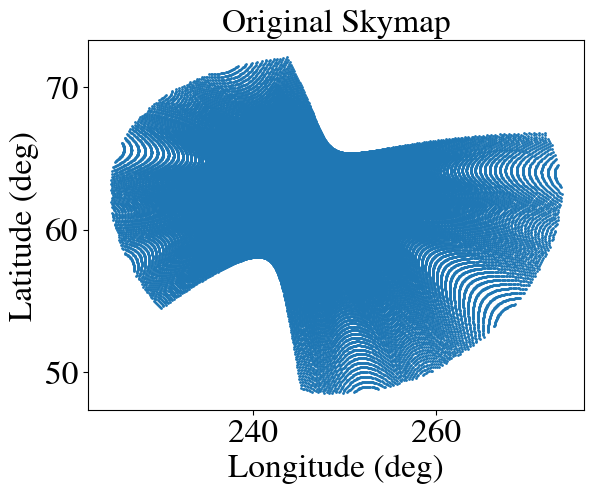

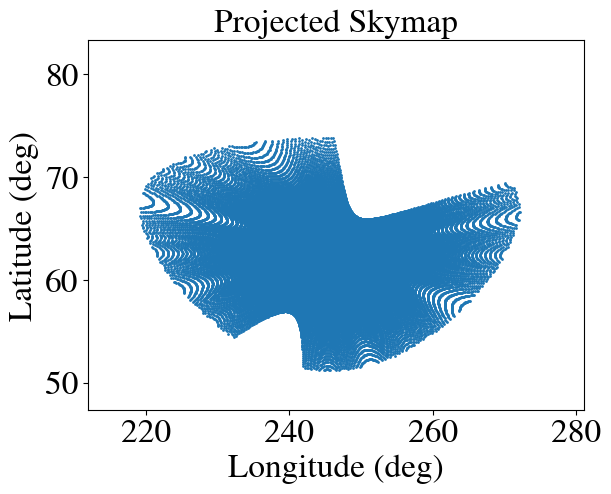

In [33]:
# original skymap
plt.figure()
plt.scatter(yknf_lon_110_arr.flatten(), yknf_lat_110_arr.flatten(), s=1, label="True Skymap")
#plt.legend()
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Original Skymap")
# plt.xlim(45, 75)
# plt.ylim(230, 270)
ax_skymap = plt.gca()
xmin, xmax = ax_skymap.get_xlim() 
ymin, ymax = ax_skymap.get_ylim()
xmin -= 10
xmax += 5
ymax += 10
x_lim = (xmin, xmax)
y_lim = (ymin, ymax)
print("X-axis limits:", x_lim)
print("Y-axis limits:", y_lim)
plt.show()

# projected skymap
plt.figure()
plt.scatter(yknf_lon_proj_110_arr.flatten(), yknf_lat_proj_110_arr.flatten(), s=1, label="Projected to 110")
#plt.legend()
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Projected Skymap")
plt.xlim(x_lim)
plt.ylim(y_lim)
# plt.xlim((np.float64(221.94879989624025-15), np.float64(276.1291877746582+15)))
# plt.ylim((np.float64(47.368554306030276-30), np.float64(73.27113227844238+30)))
plt.show()


### Overlaid: Ground Truth and Spherical Projections

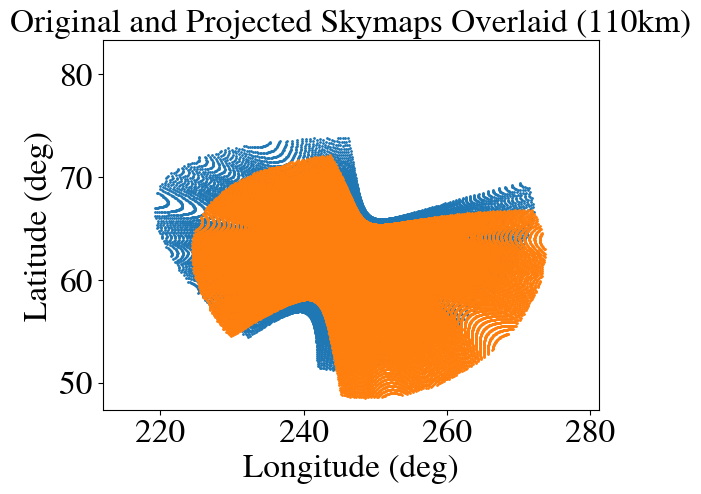

(np.float64(221.94879989624025), np.float64(276.1291877746582))
(np.float64(47.368554306030276), np.float64(73.27113227844238))


In [34]:
# original skymap
plt.figure()
plt.scatter(yknf_lon_proj_110_arr.flatten(), yknf_lat_proj_110_arr.flatten(), s=1, label="Projected to 110")
plt.scatter(yknf_lon_110_arr.flatten(), yknf_lat_110_arr.flatten(), s=1, label="True Skymap")

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Original and Projected Skymaps Overlaid (110km)")
plt.xlim(x_lim)
plt.ylim(y_lim)
# plt.xlim((np.float64(221.94879989624025-50), np.float64(276.1291877746582+50)))
# plt.ylim((np.float64(47.368554306030276-30), np.float64(73.27113227844238+30)))
plt.show()

print(ax_skymap.get_xlim())
print(ax_skymap.get_ylim())

# check azimuth, elevation cutoff (mine is not restricted) 
# look at individual pixels near the center --> check rotation 
# static num for latitude error 

### Overlaid Plot (rgb ground truth + spherical model projections)

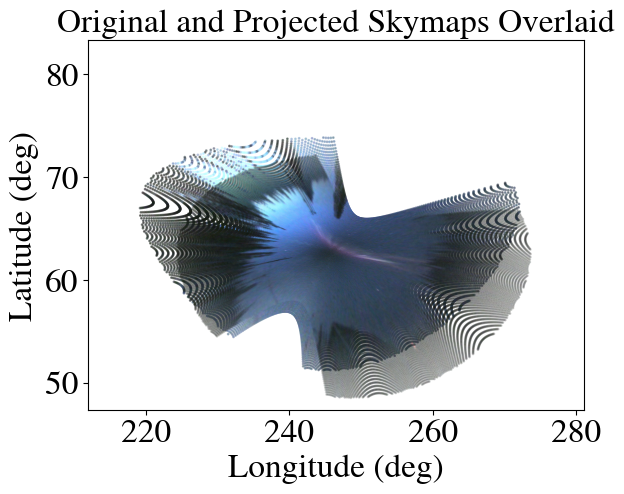

(np.float64(221.94879989624025), np.float64(276.1291877746582))
(np.float64(47.368554306030276), np.float64(73.27113227844238))


In [39]:
# get rgb
sphere_yknf_rgb, sphere_fsmi_rgb = mod_plot_lat_lon(yknf_rgb_asi_ds, 
                                                     fsmi_rgb_asi_ds, 
                                                     time_index, 
                                                     site_name_yknf, 
                                                     site_name_fsmi, 
                                                     yknf_lat_proj_110_arr, 
                                                     yknf_lon_proj_110_arr, 
                                                     fsmi_lat_proj_110_arr, 
                                                     fsmi_lon_proj_110_arr,
                                                     h_target)

base_yknf_rgb, base_fsmi_rgb = mod_plot_lat_lon(yknf_rgb_asi_ds, 
                                                 fsmi_rgb_asi_ds, 
                                                 time_index, 
                                                 site_name_yknf, 
                                                 site_name_fsmi, 
                                                 yknf_lon_110_arr, 
                                                 yknf_lat_110_arr, 
                                                 fsmi_lat_110_arr, 
                                                 fsmi_lon_110_arr,
                                                 h_target)

# original skymap
plt.figure()
plt.scatter(yknf_lon_proj_110_arr.flatten(), yknf_lat_proj_110_arr.flatten(), c=sphere_yknf_rgb.reshape(-1, 3)/256, s=1, alpha=0.5, label="Projected to 110")
plt.scatter(yknf_lon_110_arr.flatten(), yknf_lat_110_arr.flatten(), c=base_yknf_rgb.reshape(-1, 3)/256, s=1, alpha=0.2, label="True Skymap")

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Original and Projected Skymaps Overlaid")
plt.xlim(x_lim)
plt.ylim(y_lim)
# plt.xlim((np.float64(221.94879989624025-50), np.float64(276.1291877746582+50)))
# plt.ylim((np.float64(47.368554306030276-30), np.float64(73.27113227844238+30)))
plt.show()

print(ax_skymap.get_xlim())
print(ax_skymap.get_ylim())

# check azimuth, elevation cutoff (mine is not restricted) 
# look at individual pixels near the center --> check rotation 
# static num for latitude error 

### Overlaying Pixels -- Difference between skymap and my projection
- try one frame
- try averaging a few frames --> do time slices over the entire hour

(480, 553, 3)


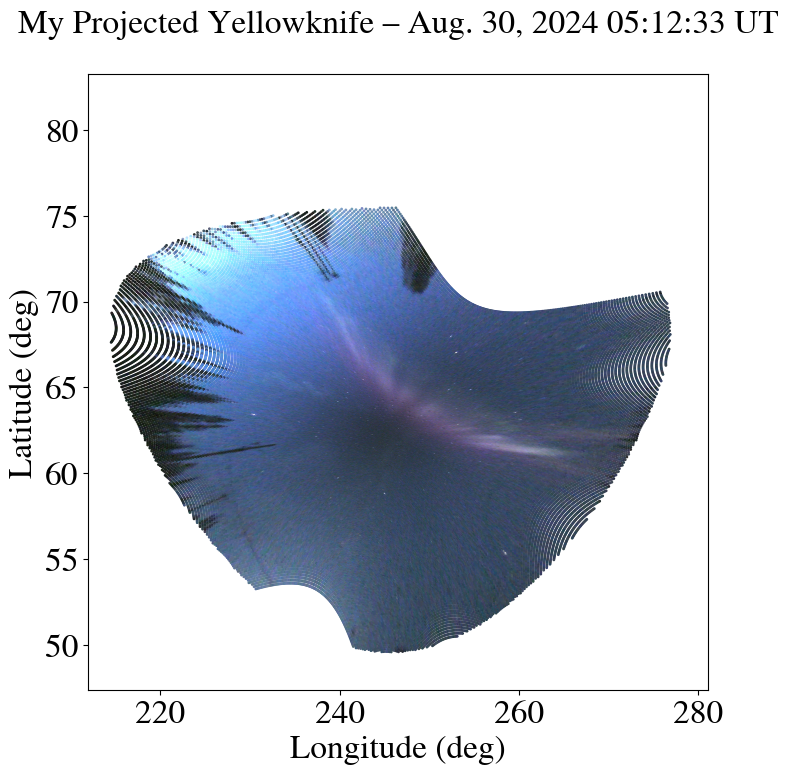

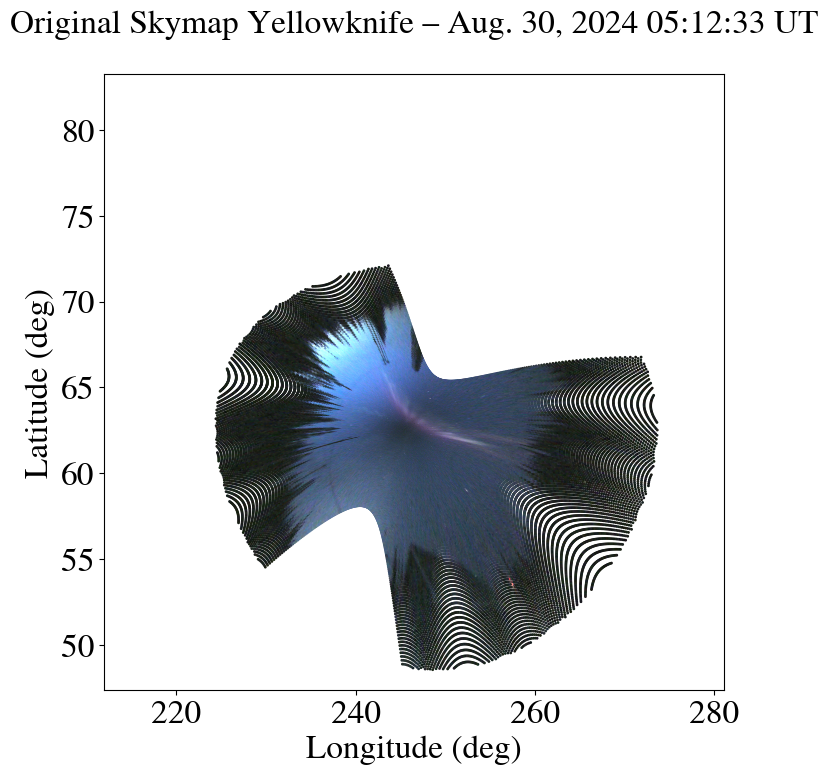

In [8]:
time_index = 251 # look at 5:10 UTC

R = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
#RGB = yknf_rgb_asi_ds.image.isel(times=time_index).values

# Extract time and format it
raw_time = yknf_rgb_asi_ds.times.values[time_index]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

# Site label - can adjust to allow for different sites!
site_name_yknf = "Yellowknife" ## CHANGE FOR DIFF SITE
site_name_yknf_short = "yknf" ## CHANGE FOR DIFF SITE

# contrast adjustment: alpha=contrast, beta=brightness
alpha = 5
beta = 5
rgb = np.stack([R, G, B], axis=-1)  # shape: (x, y, 3)
rgb_yknf_adjusted = cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta)
#rgb_yknf_adjusted = rgb_yknf_adjusted[yknf_110_mask].reshape(-1, 3) # needed for after masking done on az/el & projected lat/lon
print(rgb_yknf_adjusted.shape)

# yknf projected
fig1, ax1 = plt.subplots(figsize=(8,8))
scat = ax1.scatter(lon_proj_110_arr.flatten(),lat_proj_110_arr.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1)
# plt.xlim(ax_skymap.get_xlim())
# plt.ylim(ax_skymap.get_ylim())
plt.xlim(x_lim)
plt.ylim(y_lim)
ax1.set_ylabel("Latitude (deg)")
ax1.set_xlabel("Longitude (deg)")
ax1.set_title(f"My Projected {site_name_yknf} – {time_str}", pad=30);
plt.show()

# yknf given skymap
fig2, ax2 = plt.subplots(figsize=(8,8))
scat = ax2.scatter(lon_110_arr.flatten(),lat_110_arr.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1)
# plt.xlim(ax_skymap.get_xlim())
# plt.ylim(ax_skymap.get_ylim())
plt.xlim(x_lim)
plt.ylim(y_lim)
ax2.set_ylabel("Latitude (deg)")
ax2.set_xlabel("Longitude (deg)")
ax2.set_title(f"Original Skymap {site_name_yknf} – {time_str}", pad=30);
plt.show()


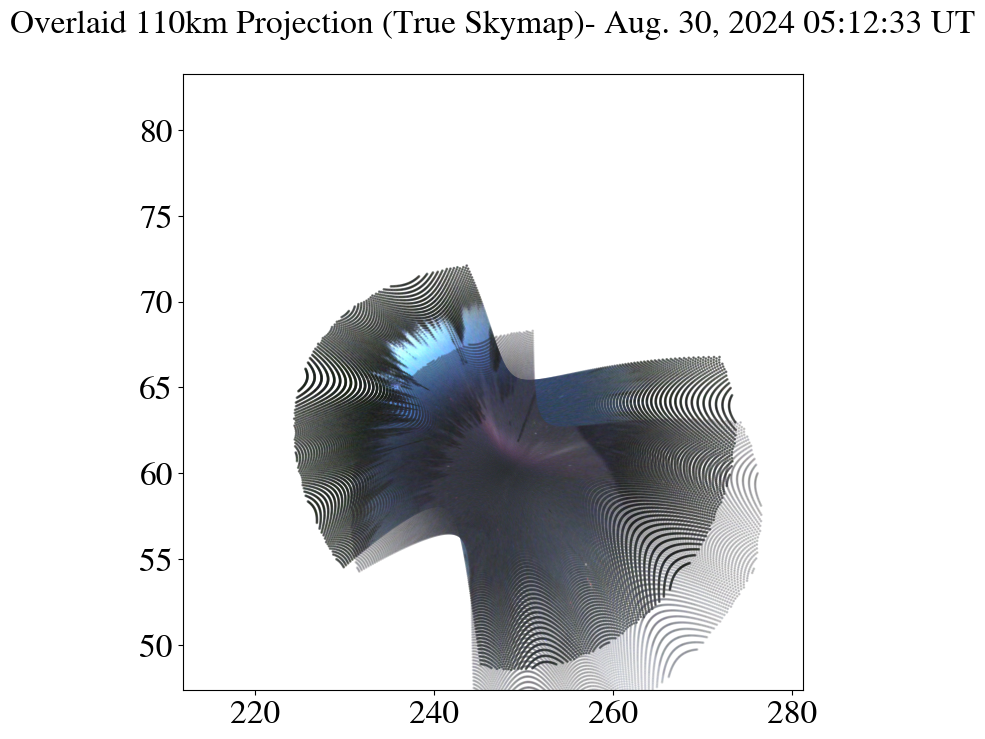

In [9]:
time_index = 251 # look at 5:10 UTC

R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values

R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values


# Extract time and format it
raw_time = yknf_rgb_asi_ds.times.values[time_index]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

# contrast adjustment: alpha=contrast, beta=brightness
alpha = 5
beta = 5
rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)  # shape: (x, y, 3)
rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)  # shape: (x, y, 3)

rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)
rgb_fsmi_adjusted = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta)

# 110km overlaid (given projection)
yknf_lat_110_arr = np.array(yknf_rgb_asi_ds["lat_110"])
yknf_lon_110_arr = np.array(yknf_rgb_asi_ds["lon_110"])
fsmi_lat_110_arr = np.array(fsmi_rgb_asi_ds["lat_110"])
fsmi_lon_110_arr = np.array(fsmi_rgb_asi_ds["lon_110"])

plt.figure(figsize=(8,8))
plt.scatter(yknf_lon_110_arr.flatten(),yknf_lat_110_arr.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1, alpha=0.5)
plt.scatter(fsmi_lon_110_arr.flatten(),fsmi_lat_110_arr.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1, alpha=0.2)
# plt.xlim(ax_skymap.get_xlim())
# plt.ylim(ax_skymap.get_ylim())
plt.xlim(x_lim)
plt.ylim(y_lim)
plt.title(f"Overlaid 110km Projection (True Skymap)- {time_str}", pad=30)
ax2.set_ylabel("Latitude (deg)")
ax2.set_xlabel("Longitude (deg)")
ax2.set_title(f"Original Skymap {site_name_yknf} – {time_str}", pad=30);
plt.show()


# # 110km overlaid (my projection)
# plt.figure(figsize=(8,8))
# plt.scatter(yknf_lon_proj_110_arr.flatten(),yknf_lat_proj_110_arr.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1, alpha=1)
# plt.scatter(fsmi_lon_proj_110_arr.flatten(),fsmi_lat_proj_110_arr.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1, alpha=0.3)
# plt.xlabel("Longitude (deg)")
# plt.ylabel("Latitude (deg)")
# plt.title("Overlaid 110km Projection - {time_str}", pad=30)
# plt.xlim(ax_skymap.get_xlim())
# plt.ylim(ax_skymap.get_ylim())
# plt.show()


In [10]:
def project_lat_lon(az_arr, el_arr, lat_camera, lon_camera, h, skymap_110_mask):
    '''
    Projected the azimuth and elevation arrays to the specified height.
    
    Parameters: 
        az_arr = 2D azimuth array for each pixel (NaNs ok, degrees, xarray)
        el_arr = 2D elevation array for each pixel (NaNs ok, degrees, xarray, no need to be filtered)
        lat_camera = latitude of camera (degrees) --> shape [480, 553]
        lon_camera = longitude of camera (degrees) --> shape [480, 553]
        h = height you want to project azimuth and elevation to to get latitude and longitude for each pixel
        skymap_110_mask = mask for where the latitude and longitude are NaNs in the ground truth lat110 and lon110 projections

    Outputs:
        lat_aurora_arr = latitudes of the aurora projected to given height h
        lon_aurora_arr = longitudes of the aurora project to give height h 
    '''

    # convert to radians + applying mask 
    el_arr = np.radians(np.array(el_arr))
    az_arr = np.radians(np.array(az_arr))
    
    # create elevation mask (True when valid)
    el_mask = (el_arr > np.radians(5)) & (el_arr < np.radians(90))
    
    # combine with skymap mask: True = valid pixel
    valid_mask = el_mask & (~skymap_110_mask)
    
    # set invalid pixels to NaN
    el_arr[~valid_mask] = np.nan
        
    # horizontal distance between camera and aurora along camera's tangent plane
    d1_arr = h / np.tan(el_arr)

    # decompose horizontal distance into east and north components relative to camera tan plane
    dx_arr = d1_arr * np.sin(az_arr)
    dy_arr = d1_arr * np.cos(az_arr)

    # convert N/E offset components to (lat, lon) --> comes out in decimal degrees 
    lat_delta_arr = dy_arr / 111045 #degrees
    lon_delta_arr = dx_arr / (np.cos(np.radians(lat_camera + lat_delta_arr)) * 111321) 

    # add lat/long offset to camera's og lat/lon to get the lat/lon of the aurora at the chosen height!
    lat_aurora_arr = lat_camera + lat_delta_arr
    lon_aurora_arr = lon_camera + lon_delta_arr

    # apply the same mask again just in case 
    lat_aurora_arr[skymap_110_mask] = np.nan
    lon_aurora_arr[skymap_110_mask] = np.nan

    return lat_aurora_arr, lon_aurora_arr

In [11]:
yknf_lat_110_proj, yknf_lon_110_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_110_proj, fsmi_lon_110_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


NameError: name 'full_azimuth_fsmi' is not defined

In [ ]:
def plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, site_name_yknf, site_name_fsmi, yknf_lat, yknf_lon, fsmi_lat, fsmi_lon):
    ''' 
    Plots the projected latitude and longitude of the YKNF and FSMI, and overlays them. 
    Produces 3 plots total: YKNF, FSMI, overlaid, and saves each of the images. 

    Parameters:
        yknf_rgb_asi_ds: xarray of the yknf skymap <xarray>
        fsmi_rgb_asi_ds: xarray of the fsmi skymap <xarray>
        time_index: specific frame we are looking at from the asi ds <int>
        site_name_yknf: string to label the plots
        site_name_fsmi: string to label the plots
        yknf_lat: projected latitude array of one yknf frame <2d arr>
        yknf_lon: projected longitude array of one yknf frame <2d arr>
        fsmi_lat: projected latitude array of one fsmi frame <2d arr>
        fsmi_lon: projected longitude array of one fsmi frame <2d arr>
        h_target: height that yknf & fsmi frames were projected to <int>
        lat_lon_plots: folder to save the 3 images to 

    Outputs:
        3 plots of the YKNF, FSMI, overlaid latitude and longitude
    '''    
    
    R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
    
    R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
    
    
    # Extract time and format it
    raw_time = yknf_rgb_asi_ds.times.values[time_index]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")
        
    # contrast adjustment: alpha=contrast, beta=brightness
    alpha = 5
    beta = 5
    rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)  # shape: (x, y, 3)
    rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)  # shape: (x, y, 3)
    
    rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)
    rgb_fsmi_adjusted = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta)
    
    # yknf projected
    fig1, ax1 = plt.subplots(figsize=(8,8))
    scat1 = ax1.scatter(yknf_lon_proj_110_arr.flatten(),yknf_lat_proj_110_arr.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1)
    plt.xlim(ax_skymap.get_xlim())
    plt.ylim(ax_skymap.get_ylim())
    ax1.set_ylabel("Latitude (deg)")
    ax1.set_xlabel("Longitude (deg)")
    ax1.set_title(f"110km Projection: {site_name_yknf} – {time_str}", pad=30);
    plt.show()
    
    # fsmi projected
    fig2, ax2 = plt.subplots(figsize=(8,8))
    scat2 = ax2.scatter(fsmi_lon_proj_110_arr.flatten(),fsmi_lat_proj_110_arr.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1)
    plt.xlim(ax_skymap.get_xlim())
    plt.ylim(ax_skymap.get_ylim())
    ax2.set_ylabel("Latitude (deg)")
    ax2.set_xlabel("Longitude (deg)")
    ax2.set_title(f"110km Projection: {site_name_fsmi} – {time_str}", pad=30);
    plt.show()
    
    # 110km  overlaid --> 
    plt.figure(figsize=(8,8))
    plt.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1, alpha=0.5)
    plt.scatter(fsmi_lon.flatten(),fsmi_lat.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1, alpha=0.02)
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(f"Overlaid {h_target}km Projection - {time_str}", pad=30)
    plt.xlim(ax_skymap.get_xlim())
    plt.ylim(ax_skymap.get_ylim())
    plt.show()

    return rgb_yknf_adjusted, rgb_fsmi_adjusted


In [ ]:
yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_110_proj, 
                                 yknf_lon_110_proj, 
                                 fsmi_lat_110_proj, 
                                 fsmi_lon_110_proj)